In [ ]:
#%%javascript
%%writefile stencil.cu

#include <stdio.h>
#include <stdlib.h>
#include <cstdlib>
#include <cstdint>
#include <unistd.h>

static bool write_pgm_p5(const char *path, const uint8_t *gray, unsigned int w, unsigned int h);
static bool read_pgm_p5(const char *path, uint8_t **gray, unsigned int *w, unsigned int *h);

__constant__ float stencil[3][3] = {
  {0, -1, 0},
  {-1, 5, -1},
  {0, -1, 0}
};


void dataTransfer(uint8_t *to, uint8_t *from, size_t length, cudaMemcpyKind direction){
    cudaError_t error;
    error = cudaMemcpy(to, from, length * sizeof(uint8_t), (cudaMemcpyKind)direction);
    if(error != cudaSuccess){
            printf("dataTransfer error: %s\n", cudaGetErrorString(error));
            exit(2);
    }
}
void gpuMalloc(uint8_t **d_g, size_t length){
    cudaError_t error;
    error = cudaMalloc ((void **) d_g, length * sizeof(uint8_t));
    if(error != cudaSuccess){
            printf("gpuMalloc error: %s\n", cudaGetErrorString(error));
            exit(1);
    }
}
void gpuFree(uint8_t *d_g){
    cudaError_t error;
    error = cudaFree(d_g);
    if(error != cudaSuccess){
            printf("gpuFree error: %s\n", cudaGetErrorString(error));
            exit(3);
    }

}
void synchronizeKernel(){
    cudaError_t error;
    error = cudaDeviceSynchronize();
    if(error != cudaSuccess){
            printf("Kernel Launch Failed\n");
            exit(4);
    }
}


__global__ void stencilKernelShared(uint8_t *imageIn, uint8_t *imageOut, unsigned int width, unsigned int height, size_t stencilRadius){
    // Compute global pixel coordinates
    unsigned int col = blockIdx.x * blockDim.x + threadIdx.x;
    unsigned int row = blockIdx.y * blockDim.y + threadIdx.y;

    // Shared memory tile dimensions (block + halo)
    unsigned int shared_width = blockDim.x + 2 * stencilRadius;
    unsigned int shared_height = blockDim.y + 2 * stencilRadius;

    // Dynamic shared memory for image tile
    extern __shared__ uint8_t tile[];

    // Load pixels into shared memory (including halo)
    for(unsigned int i = threadIdx.y; i < shared_height; i += blockDim.y) {
        for(unsigned int j = threadIdx.x; j < shared_width; j += blockDim.x) {
            int global_x = blockIdx.x * blockDim.x + j - stencilRadius;
            int global_y = blockIdx.y * blockDim.y + i - stencilRadius;

            if(global_x >= 0 && global_x < (int)width && global_y >= 0 && global_y < (int)height) {
                tile[i * shared_width + j] = imageIn[global_y * width + global_x];
            } else {
                tile[i * shared_width + j] = 0;
            }
        }
    }

    __syncthreads();

    // Apply stencil
    if(col < width && row < height) {
        float sum = 0.0;
        unsigned int shared_x = threadIdx.x + stencilRadius;
        unsigned int shared_y = threadIdx.y + stencilRadius;

        for(int i = -((int)stencilRadius); i <= (int)stencilRadius; i++) {
            for(int j = -((int)stencilRadius); j <= (int)stencilRadius; j++) {
                sum += tile[(shared_y + i) * shared_width + (shared_x + j)] * stencil[i + stencilRadius][j + stencilRadius];
            }
        }

        imageOut[row * width + col] = (uint8_t)(col == 0 || col == width-1 || row == 0 || row == height-1) ? 0 : (sum > 255 ? 255: sum) ;
    }
}



void marshallStencilKernelShared(uint8_t *imageIn, uint8_t *imageOut, unsigned int width, unsigned int height, size_t stencilRadius){

  uint8_t *imageInGPU = nullptr;
  uint8_t *imageOutGPU = nullptr;
  unsigned int pixels = width * height;
  printf("Pixels: %d\n", pixels);

  gpuMalloc(&imageInGPU, pixels);
  gpuMalloc(&imageOutGPU, pixels);

  dataTransfer(imageInGPU, imageIn, pixels, cudaMemcpyHostToDevice);

  dim3 block(16, 16, 1);
  dim3 grid((width  + block.x - 1) / block.x, (height + block.y - 1) / block.y, 1);

  printf("Block Info: %u, %u, %u \n", block.x, block.y, block.z);
  printf("Grid Info: %u, %u, %u \n", grid.x, grid.y, grid.z);

  size_t sharedMemDiameter = (block.x + 2*stencilRadius) * (block.y + 2*stencilRadius) * sizeof(uint8_t);

  stencilKernelShared <<<grid, block, sharedMemDiameter>>> (imageInGPU, imageOutGPU, width, height, stencilRadius);
  synchronizeKernel();

  dataTransfer(imageOut, imageOutGPU, pixels, cudaMemcpyDeviceToHost);
  gpuFree(imageInGPU);
  gpuFree(imageOutGPU);
}



int main(int argc, char **argv){
  if(argc < 3){
    printf("Please provide an input and output file\n");
  }
  const char *fileInPath = argv[1];
  const char *fileOutPath = argv[2];

  uint8_t *fileInData = NULL;
  uint8_t *fileOutData = NULL;

  unsigned int imageWidth = 0;
  unsigned int imageHeight = 0;
  if(!read_pgm_p5(fileInPath, &fileInData, &imageWidth, &imageHeight)){
    fprintf(stderr, "ERROR: Failed to read File: %s", fileInPath);
    exit(-1);
  }
  for(int i = 0; i < imageHeight; i++){
    for(int j = 0; j < imageWidth; j++){
      //printf("%u ", fileInData[i * imageWidth + j]);
    }
    //printf("\n");
  }

  fileOutData = (uint8_t*) calloc(imageHeight * imageWidth, sizeof(uint8_t));
  if(fileOutData == NULL){
    printf("failed to allocate space for output image\n");
    return -1;
  }

  printf("Height: %d Width: %d\n", imageHeight, imageWidth);
  size_t stencilRadius = 1;
  marshallStencilKernelShared(fileInData, fileOutData, imageWidth, imageHeight, stencilRadius);

  if(!write_pgm_p5(fileOutPath, fileOutData, imageWidth, imageHeight)){
    fprintf(stderr, "ERROR: Failed to write File: %s", fileOutPath);
    exit(-2);
  }
}









static void skip_ws_and_comments(FILE* f) {
  int c;
  while ((c = fgetc(f)) != EOF) {
    if (c == '#') { // comment line
      while ((c = fgetc(f)) != EOF && c != '\n') {}
      continue;
    }
    if (c == ' ' || c == '\n' || c == '\r' || c == '\t') continue;
    ungetc(c, f);
    break;
  }
}

static bool read_pgm_p5(const char *path, uint8_t **gray, unsigned int *w, unsigned int *h){
  FILE *fp = fopen(path, "rb");
  if (!fp) { perror("fopen"); return false; }

  char magic[3] = {0};
  if (fscanf(fp, "%2s", magic) != 1) { fclose(fp); return false; }
  if (strcmp(magic, "P5") != 0) {
    fprintf(stderr, "ERROR: %s is not P5 PGM (got %s)\n", path, magic);
    fclose(fp);
    return false;
  }

  skip_ws_and_comments(fp);

  int width = 0, height = 0, maxv = 0;
  if (fscanf(fp, "%d", &width) != 1) { fclose(fp); return false; }
  skip_ws_and_comments(fp);
  if (fscanf(fp, "%d", &height) != 1) { fclose(fp); return false; }
  skip_ws_and_comments(fp);
  if (fscanf(fp, "%d", &maxv) != 1) { fclose(fp); return false; }

  if (width <= 0 || height <= 0 || maxv != 255) {
    fprintf(stderr, "ERROR: unsupported PGM header w=%d h=%d maxv=%d (need maxv=255)\n",
            width, height, maxv);
    fclose(fp);
    return false;
  }

  fgetc(fp); // consume one whitespace char after maxv

  size_t nbytes = (size_t)width * (size_t)height;
  uint8_t *buf = (uint8_t*)malloc(nbytes);
  if (!buf) { fclose(fp); return false; }

  size_t got = fread(buf, 1, nbytes, fp);
  fclose(fp);

  if (got != nbytes) {
    fprintf(stderr, "ERROR: short read. expected %zu bytes, got %zu\n", nbytes, got);
    free(buf);
    return false;
  }

  *gray = buf;  // assign to const pointer
  *w = width;
  *h = height;
  return true;
}

static bool write_pgm_p5(const char* path, const uint8_t* gray, unsigned int w, unsigned int h){
  FILE* fp = fopen(path, "wb");
  if (!fp) { perror("fopen"); return false; }
  fprintf(fp, "P5\n%d %d\n255\n", w, h);
  size_t nbytes = (size_t)w * (size_t)h;
  size_t wrote = fwrite(gray, 1, nbytes, fp);
  fclose(fp);
  return wrote == nbytes;
}


Writing Assignment_5.cu


In [ ]:
# @title
%%writefile makefile
CC = nvcc

# Compiler flags //unecessary compiler flags // -Wall: warnings -g: debug info
CFLAGS = -Xcudafe --diag_suppress=2464 -arch=sm_75

# Source files
SRCS = stencil.cu

# Object files
OBJS = $(SRCS:.cu=.o)

# Executable name
TARGET = assignment5

# Default target
all: $(TARGET)

# Linking the executable // $@ sourcefile $^ all files/prerequesites
$(TARGET): $(OBJS)
	$(CC) $(CFLAGS) -o $@ $^

# Compiling .c to .o //$< sourcefile $@ generated file name
%.o: %.cu
	$(CC) $(CFLAGS) -c $< -o $@

# Clean up // build clean
clean:
	rm -f $(OBJS) $(TARGET)
.PHONY: all clean

Writing makefile


In [71]:
!make clean

rm -f Assignment_5.o assignment5


In [3]:
!make

nvcc -Xcudafe --diag_suppress=2464 -arch=sm_75 -c Assignment_5.cu -o Assignment_5.o
nvcc -Xcudafe --diag_suppress=2464 -arch=sm_75 -o assignment5 Assignment_5.o


In [ ]:
!./stencil input.pgm output.pgm

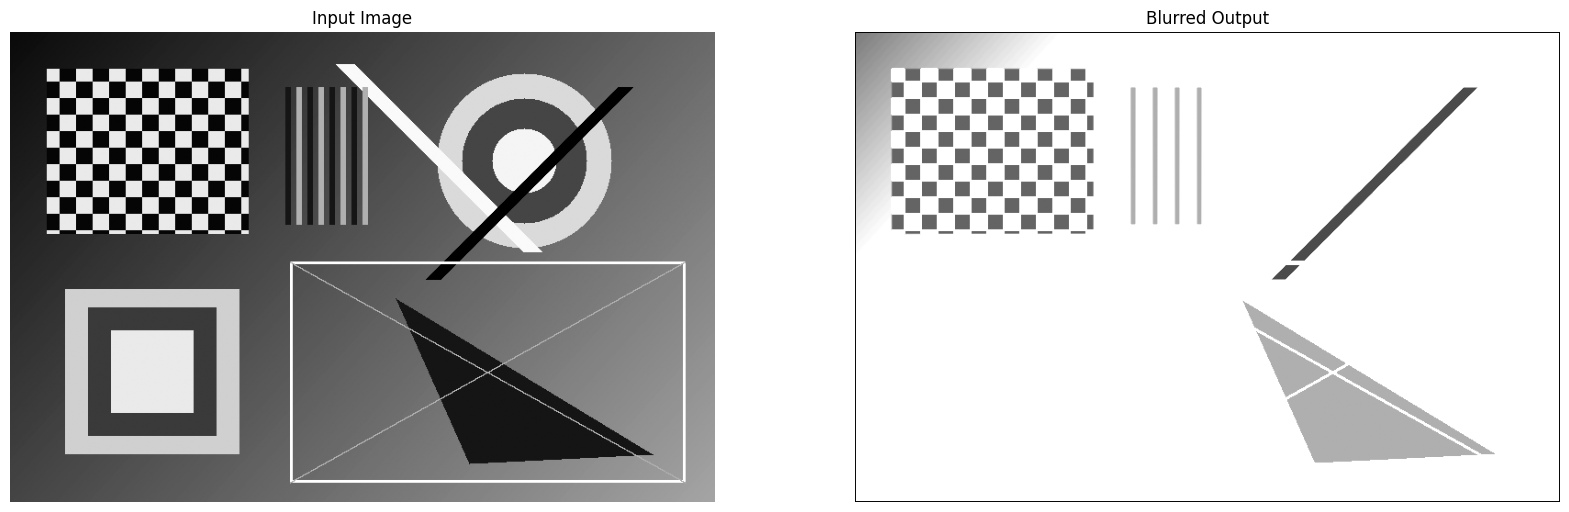

In [5]:
import matplotlib.pyplot as plt
import cv2

# Read images
input_img = cv2.imread('input.pgm', cv2.IMREAD_GRAYSCALE)

output_img = cv2.imread('output.pgm', cv2.IMREAD_GRAYSCALE)  # CUDA output is grayscale

# Display side by side
plt.figure(figsize=(20,10))

plt.subplot(1,2,1)
plt.imshow(input_img, cmap='gray')
plt.title("Input Image")
plt.axis('off')

plt.subplot(1,2,2)
plt.imshow(output_img, cmap='gray')
plt.title("Blurred Output")
plt.axis('off')

plt.show()